# Pipeline 2: Solar Radiation Estimation and Congestion Driver Analysis
## Using Sunlight Data from Space to Understand Why the Grid Gets Overloaded

<div style="background-color: #1e3a5f; color: white; padding: 20px; border-radius: 8px; margin: 10px 0;">

### What is this notebook about?

You already saw Pipeline 1, which built a map showing **where** in Amsterdam the electricity grid is most at risk of getting overloaded (congested).

But knowing **where** is only half the answer. A grid engineer also needs to know **why**.

Imagine two streets, both labelled High risk on the map:

- **Street A** has hundreds of rooftop solar panels. On a sunny afternoon they all push electricity into the grid at the same time — far more than the cables were built to carry. This is called **reverse power flow**.
- **Street B** has very few solar panels, but the street is packed with restaurants, offices, and electric car chargers that all pull enormous amounts of power at once. The cables cannot keep up.

These two streets need **completely different fixes**. Street A needs batteries or smarter inverters. Street B needs thicker cables or a new electricity substation. Giving Street A thicker cables would waste millions of euros and still leave the solar problem unsolved.

**This notebook answers the "why" question.** It loads monthly sunlight measurements from a satellite called Meteosat SEVIRI and maps them onto the same 2,217 one-kilometre squares that Pipeline 1 created. Then it classifies every high-risk square as either **solar-driven** or **consumption-driven** congestion.

</div>

---

### What data do we use in Pipeline 2?

| Data source | What it tells us |
|---|---|
| **congestion_risk_grid.gpkg** | The 2,217 grid squares with congestion labels from Pipeline 1 |
| **CM SAF SARAH-3 SIS files** | How much sunlight (in watts per m²) hit each spot of Europe each month |

### What do we produce?

| Output | Description |
|---|---|
| **Four maps + one bar chart** | Annual sunlight, seasonal comparison, ratio map, combined driver map, monthly time series |
| **congestion_radiation_grid.gpkg** | The finished grid file combining Pipeline 1 features with radiation data and driver classification |


## Section 1: Importing Libraries

<div style="background-color: #1e4981; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
Think of Python as a very smart but completely empty toolbox. Before we can open map files, read satellite data, or draw charts, we need to load the right tools. These tools are called **libraries** -- collections of code written by other programmers that we can use for free.

</div>

<div style="background-color: #1e703b; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
Without libraries, we would have to write thousands of lines of code ourselves just to open a file or calculate an average. One `import` line gives us that power instantly. If any library is missing, the first code cell automatically installs it so the notebook can always run.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**
Each `import` line loads one library into memory. Here is what each one does in plain English:

| Library | What it does |
|---|---|
| `xarray` | Opens weather and climate files from satellites (NetCDF format) |
| `netCDF4` | Provides the engine that `xarray` uses to read those files |
| `numpy` | Does fast maths on large tables of numbers -- averages, ratios, comparisons |
| `pandas` | Works with data tables (like Excel, but in Python) |
| `geopandas` | Opens, edits, and saves geographic map files with geometry attached |
| `matplotlib` | Draws charts, maps, and graphs |
| `pathlib` | Handles file paths in a clean, readable way across Windows and Mac |
| `glob` | Finds all files matching a pattern (e.g. all `.nc` files in a folder) |

</div>


In [1]:
# Install xarray and netcdf4 if not present
try:
    import xarray as xr
    print("xarray already installed:", xr.__version__)
except ImportError:
    print("Installing xarray and netcdf4...")
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xarray', 'netcdf4'])
    import xarray as xr
    print("Installed xarray:", xr.__version__)

Installing xarray and netcdf4...
Installed xarray: 2026.4.0


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm, ListedColormap
from pathlib import Path
from scipy.interpolate import RegularGridInterpolator

print("All imports successful.")
print(f"  numpy     {np.__version__}")
print(f"  pandas    {pd.__version__}")
print(f"  geopandas {gpd.__version__}")
print(f"  xarray    {xr.__version__}")

All imports successful.
  numpy     2.2.2
  pandas    2.2.3
  geopandas 1.1.3
  xarray    2026.4.0


## Section 2: Configuration -- File Paths and Settings

<div style="background-color: #254774; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are writing down all the important settings in one place at the top of the notebook -- file locations, coordinate system names, and the rectangle of the map that covers Amsterdam. This is the only cell you would need to change if you moved the data to a different folder or wanted to study a different city.

</div>

<div style="background-color: #1c6435; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
Imagine writing a file path like `C:/Nikola/Year 3/Semester 5/Notebook/...` fifty times throughout the notebook. If you ever move the data folder, you would have to fix it fifty times and would certainly miss one. By defining it once here, the rest of the notebook just refers to `BASE_DIR` -- one change fixes everything.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**
Here is what each constant means:

| Constant | What it stores | Plain-English meaning |
|---|---|---|
| `BASE_DIR` | Root folder path | The folder where the whole project lives |
| `CONGESTION_GRID_PATH` | Path to Pipeline 1 output | The map file we load from Pipeline 1 |
| `RADIATION_DIR` | Path to SIS NetCDF folder | The folder containing the monthly sunlight files |
| `GRID_CRS` | `'EPSG:28992'` | The Dutch coordinate system -- distances in metres from a fixed Dutch reference point |
| `WGS84` | `'EPSG:4326'` | Standard GPS latitude/longitude coordinates used worldwide |
| `BBOX` | Four numbers | The rectangle around Amsterdam: minimum latitude, maximum latitude, minimum longitude, maximum longitude |

The **bounding box** (`BBOX`) crops the satellite data to the Amsterdam region only. The Meteosat satellite covers all of Europe -- loading the full dataset would waste memory. We only keep the small rectangle that overlaps our 15 km buffer around Amsterdam.

</div>


In [3]:
from pathlib import Path

BASE_DIR = Path('C:/Nikola/Year 3/Semester 5/Notebook')
RADIATION_DIR = BASE_DIR / 'Data' / 'Radiation'
CONGESTION_GRID_PATH = BASE_DIR / 'congestion_risk_grid.gpkg'

GRID_CRS = 'EPSG:28992'   # Dutch RD New -- used by Pipeline 1 grid
WGS84_CRS = 'EPSG:4326'   # Geographic lat/lon -- used by CM SAF SIS

# Amsterdam study area bounding box in WGS84
BBOX = {
    'lat_min': 52.143,
    'lat_max': 52.574,
    'lon_min': 4.507,
    'lon_max': 5.331,
}

# Season mapping: month number -> season name
MONTH_TO_SEASON = {
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn',
    12: 'winter', 1: 'winter', 2: 'winter',
}

print(f"BASE_DIR:          {BASE_DIR}")
print(f"RADIATION_DIR:     {RADIATION_DIR}")
print(f"CONGESTION_GRID:   {CONGESTION_GRID_PATH}")
print(f"Study area bbox:   lat [{BBOX['lat_min']}, {BBOX['lat_max']}], "
      f"lon [{BBOX['lon_min']}, {BBOX['lon_max']}]")

BASE_DIR:          C:\Nikola\Year 3\Semester 5\Notebook
RADIATION_DIR:     C:\Nikola\Year 3\Semester 5\Notebook\Data\Radiation
CONGESTION_GRID:   C:\Nikola\Year 3\Semester 5\Notebook\congestion_risk_grid.gpkg
Study area bbox:   lat [52.143, 52.574], lon [4.507, 5.331]


## Section 3: Loading the Congestion Grid from Pipeline 1

<div style="background-color: #21487a; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are opening the map file that Pipeline 1 saved -- `congestion_risk_grid.gpkg` -- which contains all 2,217 one-kilometre grid squares covering Amsterdam. Each square already has its congestion class (Low / Medium / High), PV penetration, feed-in ratio, and satellite features attached. We load that file here so we can add radiation data to the same squares.

</div>

<div style="background-color: #27693e; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
This is the handoff point between Pipeline 1 and Pipeline 2. Instead of rebuilding the grid from scratch, we simply pick up where Pipeline 1 left off. This guarantees that the 2,217 cells in Pipeline 2 are **exactly** the same shape, size, and position as the cells in Pipeline 1 -- so when we add radiation columns, they line up perfectly with the congestion columns already there.

</div>

<div style="background-color: #88731e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

1. `gpd.read_file(CONGESTION_GRID_PATH)` opens the GeoPackage. A **GeoPackage** is like a zip file that holds both a data table and the map geometry (the square outlines) in one portable file.
2. The grid is stored in the Dutch coordinate system (EPSG:28992), where X and Y values are distances in metres from a fixed Dutch reference point.
3. We create a second copy called `grid_wgs` using `.to_crs(WGS84)`. This converts the squares' coordinates into GPS latitude/longitude. We need this because the Meteosat satellite data uses lat/lon, not Dutch metres -- the two systems speak different languages and must be translated before we can match them.

Think of it like converting a map from Dutch kilometres into GPS degrees so two different satellites can finally talk to each other.

</div>


In [4]:
grid = gpd.read_file(CONGESTION_GRID_PATH)
print(f"Loaded {len(grid)} grid cells from Pipeline 1")
print(f"CRS:     {grid.crs}")
print(f"Columns: {grid.columns.tolist()}")
print()
grid.head(3)

Loaded 2217 grid cells from Pipeline 1
CRS:     EPSG:28992
Columns: ['cell_id', 'congestion_score', 'congestion_class', 'congestion_label', 'pred_class', 'pred_label', 'pred_proba_high', 'pv_penetration', 'pv_penetration_pct', 'pv_kw_per_conn', 'feedin_kwh', 'feedin_ratio', 'consumption_kwh', 'consumption_pct', 'ndbi_pct', 'land_use_type', 'bevolkingsdichtheid_inwoners_per_km2', 'omgevingsadressendichtheid', 'stedelijkheid_adressen_per_km2', 'gemiddeld_elektriciteitsverbruik_totaal', 'woningvoorraad', 'percentage_meergezinswoning', 'percentage_koopwoningen', 'geometry']



,cell_id,congestion_score,congestion_class,congestion_label,pred_class,pred_label,pred_proba_high,pv_penetration,pv_penetration_pct,pv_kw_per_conn,...,ndbi_pct,land_use_type,bevolkingsdichtheid_inwoners_per_km2,omgevingsadressendichtheid,stedelijkheid_adressen_per_km2,gemiddeld_elektriciteitsverbruik_totaal,woningvoorraad,percentage_meergezinswoning,percentage_koopwoningen,geometry
0,0,NaN,NaN,None,0,Low,0.216978,NaN,NaN,NaN,...,82.7,Residential / Mixed,-66664.333333,-32820.666667,-33329.666667,-99995.0,-99995.0,-99995.0,-99995.0,"POLYGON ((96193.612 484714.922, 96193.612 4857..."
1,1,NaN,NaN,None,0,Low,0.078932,NaN,NaN,NaN,...,77.3,Industrial / Commercial,-49362.500000,-24398.500000,-24996.250000,-99995.0,-99995.0,-99995.0,-99995.0,"POLYGON ((96193.612 485714.922, 96193.612 4867..."
2,2,NaN,NaN,None,0,Low,0.043298,NaN,NaN,NaN,...,78.9,Industrial / Commercial,-30820.000000,-15606.166667,-16663.500000,-99995.0,-99995.0,-99995.0,-99995.0,"POLYGON ((96193.612 486714.922, 96193.612 4877..."


In [5]:
# Reproject to WGS84 for matching with SIS lat/lon coordinates
grid_wgs = grid.to_crs(WGS84_CRS)
print(f"Reprojected grid CRS: {grid_wgs.crs}")

# Quick sanity check -- centroids should fall inside Amsterdam
centroids = grid_wgs.geometry.centroid
print(f"Centroid lat range: [{centroids.y.min():.4f}, {centroids.y.max():.4f}]")
print(f"Centroid lon range: [{centroids.x.min():.4f}, {centroids.x.max():.4f}]")

Reprojected grid CRS: EPSG:4326
Centroid lat range: [52.1471, 52.5695]
Centroid lon range: [4.5146, 5.3241]


C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\1070904713.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid_wgs.geometry.centroid


## Section 4: Scanning and Loading the Solar Radiation Files

<div style="background-color: #26456d; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are loading 27 monthly sunlight measurement files produced by the **Meteosat SEVIRI** satellite. Each file covers one calendar month and tells us how much solar energy (in watts per square metre) reached the ground across Europe. We crop each file to the small rectangle around Amsterdam and keep the values in memory.

</div>

<div style="background-color: #1c6435; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
Knowing how much sunlight a grid cell receives is essential for understanding congestion. A neighbourhood with strong sunlight AND many solar panels is a very different problem from one with weak sunlight AND high electricity demand. We need 27 months of data (two full years plus a few extra months) to compute reliable seasonal averages -- a single month could be unusually cloudy or unusually sunny and give a misleading picture.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

**What is a NetCDF file?**
Think of it as a special kind of Excel file used by scientists and space agencies. Instead of rows and columns of text, it holds a grid of numbers where:
- Each **row** is a latitude (how far north or south)
- Each **column** is a longitude (how far east or west)
- The **number at each position** is the radiation value for that location in that month

**What is SIS?**
SIS stands for **Surface Incoming Shortwave radiation** -- the scientific name for the sunlight that actually reaches the ground after some is reflected back by clouds and the atmosphere. It is measured in **W/m²** (watts per square metre).

**How do we extract the date?**
The filename contains the date: for example `SISmm20250301000000000000215SVMSG01UD.nc` contains `20250301` meaning **1 March 2025**. Python's `re` library picks the eight-digit date out of the filename automatically.

**Clipping to Amsterdam:**
The full Meteosat file covers all of Europe -- millions of data points we do not need. We immediately crop it to the bounding box rectangle around Amsterdam. This keeps memory usage low and processing fast.

</div>


In [6]:
sis_data = []

if not RADIATION_DIR.exists():
    print(f"WARNING: Radiation directory not found: {RADIATION_DIR}")
else:
    folders = sorted([f for f in RADIATION_DIR.iterdir() if f.is_dir()])
    print(f"Found {len(folders)} month folders in {RADIATION_DIR}")

    for folder in folders:
        nc_files = list(folder.glob('SIS*.nc'))
        if not nc_files:
            print(f"  {folder.name}: no SIS*.nc file found, skipping")
            continue

        nc_path = nc_files[0]
        fname = nc_path.name

        # Extract date: SISmm20250301... -> characters 5-13 give YYYYMMDD
        try:
            date_str = fname[5:13]
            year = int(date_str[:4])
            month = int(date_str[4:6])
        except (ValueError, IndexError):
            print(f"  {fname}: cannot parse date, skipping")
            continue

        try:
            ds = xr.open_dataset(nc_path)

            # Identify the SIS variable (might be 'SIS', 'sis', or similar)
            var_names = list(ds.data_vars)
            sis_var = None
            for v in var_names:
                if 'SIS' in v.upper():
                    sis_var = v
                    break
            if sis_var is None:
                sis_var = var_names[0]  # fallback

            # Identify lat/lon dimension names
            lat_name, lon_name = None, None
            for dim in list(ds.dims) + list(ds.coords):
                dl = dim.lower()
                if 'lat' in dl:
                    lat_name = dim
                elif 'lon' in dl:
                    lon_name = dim

            if lat_name is None or lon_name is None:
                print(f"  {fname}: cannot find lat/lon dims {list(ds.dims)}, skipping")
                ds.close()
                continue

            # Clip to Amsterdam bounding box
            # Try descending lat first (common for satellite products)
            sis_clip = ds[sis_var].sel(
                **{lat_name: slice(BBOX['lat_max'], BBOX['lat_min']),
                   lon_name: slice(BBOX['lon_min'], BBOX['lon_max'])}
            )
            # If empty, try ascending lat
            if sis_clip.sizes.get(lat_name, 0) == 0:
                sis_clip = ds[sis_var].sel(
                    **{lat_name: slice(BBOX['lat_min'], BBOX['lat_max']),
                       lon_name: slice(BBOX['lon_min'], BBOX['lon_max'])}
                )

            arr = sis_clip.values.squeeze()
            lats = sis_clip[lat_name].values
            lons = sis_clip[lon_name].values

            sis_data.append({
                'year': year,
                'month': month,
                'season': MONTH_TO_SEASON.get(month, 'unknown'),
                'data': arr,
                'lats': lats,
                'lons': lons,
            })

            mean_val = float(np.nanmean(arr))
            print(f"  {year}-{month:02d}: mean SIS = {mean_val:.1f} W/m2, "
                  f"shape = {arr.shape}, season = {MONTH_TO_SEASON.get(month)}")
            ds.close()

        except Exception as e:
            print(f"  {fname}: error loading -- {e}")

print(f"\nLoaded {len(sis_data)} months of SIS data in total.")

Found 27 month folders in C:\Nikola\Year 3\Semester 5\Notebook\Data\Radiation
  2023-12: mean SIS = 18.4 W/m2, shape = (8, 17), season = winter
  2024-01: mean SIS = 33.5 W/m2, shape = (8, 17), season = winter
  2024-02: mean SIS = 44.4 W/m2, shape = (8, 17), season = winter
  2024-03: mean SIS = 100.5 W/m2, shape = (8, 17), season = spring
  2024-04: mean SIS = 163.6 W/m2, shape = (8, 17), season = spring
  2024-05: mean SIS = 206.3 W/m2, shape = (8, 17), season = spring
  2024-06: mean SIS = 230.1 W/m2, shape = (8, 17), season = summer
  2024-07: mean SIS = 221.9 W/m2, shape = (8, 17), season = summer
  2024-08: mean SIS = 201.0 W/m2, shape = (8, 17), season = summer
  2024-09: mean SIS = 130.5 W/m2, shape = (8, 17), season = autumn
  2024-10: mean SIS = 74.5 W/m2, shape = (8, 17), season = autumn
  2024-11: mean SIS = 35.0 W/m2, shape = (8, 17), season = autumn
  2024-12: mean SIS = 15.0 W/m2, shape = (8, 17), season = winter
  2025-01: mean SIS = 26.6 W/m2, shape = (8, 17), season 

## Section 5: Matching Radiation Values to Grid Cells

<div style="background-color: #224e88; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are giving each of the 2,217 one-kilometre grid squares a radiation number for every month. We do this by finding which Meteosat measurement point is geographically closest to the centre of that square and copying its value.

</div>

<div style="background-color: #27693e; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
The Meteosat satellite takes one measurement roughly every **5.5 km**. Our grid squares are only **1 km** wide. This means that up to 25 of our small squares might fall inside a single Meteosat measurement area -- like 25 houses all reading the temperature from the same weather station down the street.

We need to assign a radiation value to every small square so the rest of the analysis can compare radiation with congestion risk cell by cell.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work? -- Nearest-Neighbour Assignment**

**Step 1 -- Find the centre of each grid cell.**
Each 1 km² square has a geometric centre called a **centroid**. We compute the GPS latitude and longitude of that centre point.

**Step 2 -- Find the closest Meteosat pixel.**
For each grid centroid, we search through all the Meteosat measurement positions in that month's data and find the one that is geographically closest. "Closest" means the smallest straight-line distance measured in degrees of latitude/longitude.

**Step 3 -- Copy the value.**
We copy the radiation reading of that closest pixel to our grid cell. This technique is called **nearest-neighbour interpolation**: "neighbour" because we pick the nearest measurement point, and "interpolation" because we are filling gaps in our fine grid using measurements from a coarser grid.

**Why not blend multiple pixels together?**
Blending two Meteosat pixels would create a radiation value that was never actually measured -- it would be a mathematical invention. Using the nearest real measurement is more honest. The small inaccuracy from sharing a pixel among neighbouring cells is acceptable given the 5.5 km native resolution of the satellite data.

</div>


In [7]:
# Extract centroid coordinates in WGS84
centroids = grid_wgs.geometry.centroid
cell_lats = centroids.y.values
cell_lons = centroids.x.values

print(f"Grid cells to assign: {len(cell_lats)}")
print(f"Lat range: [{cell_lats.min():.4f}, {cell_lats.max():.4f}]")
print(f"Lon range: [{cell_lons.min():.4f}, {cell_lons.max():.4f}]")

Grid cells to assign: 2217
Lat range: [52.1471, 52.5695]
Lon range: [4.5146, 5.3241]


C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\2277353749.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid_wgs.geometry.centroid


In [8]:
for rec in sis_data:
    lats = rec['lats'].copy()
    lons = rec['lons'].copy()
    data = rec['data'].copy()

    if lats is None or lons is None or data.size == 0:
        rec['cell_values'] = np.full(len(grid), np.nan)
        continue

    # RegularGridInterpolator requires strictly ascending axes
    if lats.ndim == 1 and len(lats) > 1 and lats[0] > lats[-1]:
        lats = lats[::-1]
        data = data[::-1, :]

    try:
        interp = RegularGridInterpolator(
            (lats, lons), data.astype(float),
            method='nearest',
            bounds_error=False,
            fill_value=np.nan,
        )
        points = np.column_stack([cell_lats, cell_lons])
        cell_values = interp(points)

        # Replace any sentinel fill values (CM SAF uses -999 or 9999) with NaN
        cell_values = np.where(cell_values < -100, np.nan, cell_values)
        cell_values = np.where(cell_values > 5000, np.nan, cell_values)

        rec['cell_values'] = cell_values
        valid = int(np.sum(~np.isnan(cell_values)))
        print(f"  {rec['year']}-{rec['month']:02d}: {valid} / {len(grid)} cells with valid radiation")

    except Exception as e:
        print(f"  {rec['year']}-{rec['month']:02d}: interpolation failed -- {e}")
        rec['cell_values'] = np.full(len(grid), np.nan)

print("\nRadiation mapped to all grid cells.")

  2023-12: 1933 / 2217 cells with valid radiation
  2024-01: 1933 / 2217 cells with valid radiation
  2024-02: 1933 / 2217 cells with valid radiation
  2024-03: 1933 / 2217 cells with valid radiation
  2024-04: 1933 / 2217 cells with valid radiation
  2024-05: 1933 / 2217 cells with valid radiation
  2024-06: 1933 / 2217 cells with valid radiation
  2024-07: 1933 / 2217 cells with valid radiation
  2024-08: 1933 / 2217 cells with valid radiation
  2024-09: 1933 / 2217 cells with valid radiation
  2024-10: 1933 / 2217 cells with valid radiation
  2024-11: 1933 / 2217 cells with valid radiation
  2024-12: 1933 / 2217 cells with valid radiation
  2025-01: 1933 / 2217 cells with valid radiation
  2025-02: 1933 / 2217 cells with valid radiation
  2025-03: 1933 / 2217 cells with valid radiation
  2025-04: 1933 / 2217 cells with valid radiation
  2025-05: 1933 / 2217 cells with valid radiation
  2025-06: 1933 / 2217 cells with valid radiation
  2025-07: 1933 / 2217 cells with valid radiation


## Section 6: Computing Summary Radiation Statistics per Cell

<div style="background-color: #305d99; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
After loading 27 monthly radiation values for each cell, we summarise them into a small set of meaningful numbers: the average sunlight per year, the average per season (spring / summer / autumn / winter), and the summer-to-winter ratio. These summary columns are added directly to the grid so they travel alongside the congestion features from Pipeline 1.

</div>

<div style="background-color: #268146; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
A single month's reading is not reliable on its own -- February 2024 could have been unusually cloudy, and using only that one month would underestimate the real solar potential of a neighbourhood. Averaging across two full years gives a **stable, representative** picture of each cell's sunlight climate.

The **summer-to-winter ratio** is especially important because Amsterdam sits at latitude 52°N. Summer days are very long and sunny while winter days are short and grey. A ratio of 6 or 7 means solar panels produce roughly 6--7 times more electricity in summer than in winter -- the congestion problem from solar panels is almost entirely a **summer afternoon problem**.

</div>

<div style="background-color: #88731e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

| Column name | Formula | Plain meaning |
|---|---|---|
| `GHI_annual_mean` | Average of all 27 monthly values | Typical sunlight on any day across the full year |
| `GHI_spring` | Average of March + April + May | Sunlight as solar panels start becoming productive again |
| `GHI_summer` | Average of June + July + August | Peak solar season -- when reverse power flow is most likely |
| `GHI_autumn` | Average of September + October + November | Declining sun, lower solar output |
| `GHI_winter` | Average of December + January + February | Minimum sunlight -- solar panels produce very little |
| `GHI_seasonal_ratio` | Summer mean ÷ Winter mean | How lopsided is the solar resource? Higher = more concentrated in summer |
| `GHI_annual_total_kwh` | Annual mean × 8,760 hours ÷ 1,000 | Rough total solar energy per m² per year, in kWh |

All unit values are **W/m²** (watts per square metre) unless otherwise noted. One watt per square metre of sunlight falling on a one-square-metre solar panel for one hour produces one watt-hour (Wh) of electricity.

</div>


In [9]:
# Add one column per month
for rec in sis_data:
    col_name = f"SIS_{rec['year']}_{rec['month']:02d}"
    grid[col_name] = rec['cell_values']

print(f"Added {len(sis_data)} monthly SIS columns to grid.")

Added 27 monthly SIS columns to grid.


In [10]:
# Seasonal averages
for season in ['spring', 'summer', 'autumn', 'winter']:
    season_recs = [r for r in sis_data if r['season'] == season]
    if season_recs:
        season_matrix = np.column_stack([r['cell_values'] for r in season_recs])
        grid[f'GHI_{season}'] = np.nanmean(season_matrix, axis=1)
        print(f"  GHI_{season}: mean = {grid[f'GHI_{season}'].mean():.1f} W/m2 "
              f"({len(season_recs)} months)")
    else:
        grid[f'GHI_{season}'] = np.nan
        print(f"  GHI_{season}: no data available")

# Annual mean across all loaded months
if sis_data:
    all_monthly = np.column_stack([r['cell_values'] for r in sis_data])
    grid['GHI_annual_mean'] = np.nanmean(all_monthly, axis=1)
else:
    grid['GHI_annual_mean'] = np.nan

print(f"\nGHI_annual_mean: "
      f"mean={grid['GHI_annual_mean'].mean():.1f}, "
      f"min={grid['GHI_annual_mean'].min():.1f}, "
      f"max={grid['GHI_annual_mean'].max():.1f} W/m2")

  GHI_spring: mean = 178.4 W/m2 (6 months)
  GHI_summer: mean = 223.9 W/m2 (6 months)
  GHI_autumn: mean = 79.5 W/m2 (6 months)
  GHI_winter: mean = 34.3 W/m2 (9 months)

GHI_annual_mean: mean=118.5, min=114.6, max=122.1 W/m2


C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\557280258.py:6: RuntimeWarning: Mean of empty slice
  grid[f'GHI_{season}'] = np.nanmean(season_matrix, axis=1)
C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\557280258.py:6: RuntimeWarning: Mean of empty slice
  grid[f'GHI_{season}'] = np.nanmean(season_matrix, axis=1)
C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\557280258.py:6: RuntimeWarning: Mean of empty slice
  grid[f'GHI_{season}'] = np.nanmean(season_matrix, axis=1)
C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\557280258.py:6: RuntimeWarning: Mean of empty slice
  grid[f'GHI_{season}'] = np.nanmean(season_matrix, axis=1)
C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\557280258.py:16: RuntimeWarning: Mean of empty slice
  grid['GHI_annual_mean'] = np.nanmean(all_monthly, axis=1)


In [11]:
# Summer-to-winter ratio -- indicates how strongly seasonal the radiation is
if 'GHI_summer' in grid.columns and 'GHI_winter' in grid.columns:
    grid['GHI_seasonal_ratio'] = grid['GHI_summer'] / (grid['GHI_winter'] + 1e-10)
    print(f"GHI_seasonal_ratio: mean = {grid['GHI_seasonal_ratio'].mean():.2f}")

# Approximate annual total in kWh/m2
# Monthly mean W/m2 * 730 hours per month (average) / 1000 -> kWh/m2/month
# Summed over 12 months gives annual total
if sis_data:
    monthly_totals = np.column_stack(
        [r['cell_values'] * 730 / 1000 for r in sis_data]
    )
    # Scale to represent a full year even if we have partial coverage
    n_months = len(sis_data)
    grid['GHI_annual_kWh_m2'] = np.nansum(monthly_totals, axis=1) * (12 / n_months)
    print(f"GHI_annual_kWh_m2: mean = {grid['GHI_annual_kWh_m2'].mean():.0f} kWh/m2/year")

print("\nRadiation statistics computed.")
print(grid[['GHI_annual_mean', 'GHI_summer', 'GHI_winter']].describe().round(1))

GHI_seasonal_ratio: mean = 6.54
GHI_annual_kWh_m2: mean = 905 kWh/m2/year

Radiation statistics computed.
       GHI_annual_mean  GHI_summer  GHI_winter
count           1933.0      1933.0      1933.0
mean             118.5       223.9        34.3
std                1.6         4.1         0.6
min              114.6       216.0        32.4
25%              117.1       220.7        34.0
50%              118.7       223.7        34.4
75%              119.9       227.8        34.7
max              122.1       234.3        35.4


## Section 7: Visualising the Solar Radiation Data

<div style="background-color: #183a66; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are drawing four maps and one bar chart to look at the radiation data from multiple angles before using it in any analysis. This is a **sanity check** -- we want to make sure the numbers look physically plausible before we trust them for decision-making.

</div>

<div style="background-color: #1c7039; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
**Always look at your data before you use it.** If a bug crept in during the file-loading step -- for example, reading the wrong variable from the NetCDF file or accidentally flipping latitude values upside down -- the maps would look obviously wrong. Catching this now saves hours of confused debugging later.

A correct radiation map over Amsterdam should show:
- Values that are **physically reasonable** for the Netherlands (~100--130 W/m² annual mean)
- A strong **seasonal contrast**: summer values should be 5--7× higher than winter values
- A **smooth spatial pattern** with no isolated cells showing extreme outlier values (which would suggest a data error)

</div>

<div style="background-color: #8f7922; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work? -- Four visualisations**

**Map 1 -- Annual mean GHI:**
Every cell is coloured by its average sunlight across all 27 months. The colour scale runs from green (low radiation) through yellow to red (high radiation). This gives the overall "big picture" of the solar resource across the study area.

**Map 2 -- Summer vs Winter side by side:**
Two maps placed next to each other: summer average GHI on the left, winter average GHI on the right. The dramatic difference in colour levels instantly reveals how strongly the solar resource concentrates into the summer months -- a difference a child could spot at a glance.

**Map 3 -- Seasonal ratio:**
Each cell is coloured by its summer ÷ winter ratio. A cell with ratio = 7 means it receives 7× more sunlight in summer than in winter. Areas with high ratios are where solar congestion is most likely to be a short, intense summer-afternoon problem.

**Chart 4 -- Monthly time series:**
A bar chart showing the monthly mean radiation across the entire study area from the first available month to the last. It shows the seasonal wave pattern clearly: tall bars every June--August, shallow bars every December--February. If any month had a data error, it would appear as an obvious spike or gap.

</div>


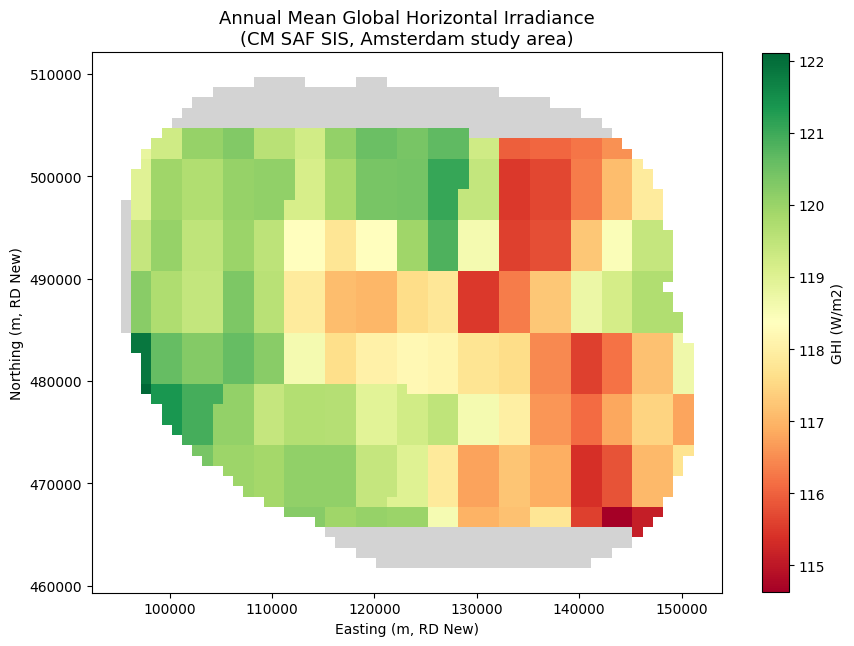

In [12]:
# 1. Annual mean GHI map
if 'GHI_annual_mean' in grid.columns and grid['GHI_annual_mean'].notna().any():
    fig, ax = plt.subplots(figsize=(9, 8))
    grid.plot(
        column='GHI_annual_mean',
        ax=ax,
        cmap='RdYlGn',
        legend=True,
        legend_kwds={'label': 'GHI (W/m2)', 'shrink': 0.7},
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    )
    ax.set_title('Annual Mean Global Horizontal Irradiance\n(CM SAF SIS, Amsterdam study area)', fontsize=13)
    ax.set_xlabel('Easting (m, RD New)')
    ax.set_ylabel('Northing (m, RD New)')
    plt.tight_layout()
    plt.show()
else:
    print("No GHI_annual_mean data to plot.")

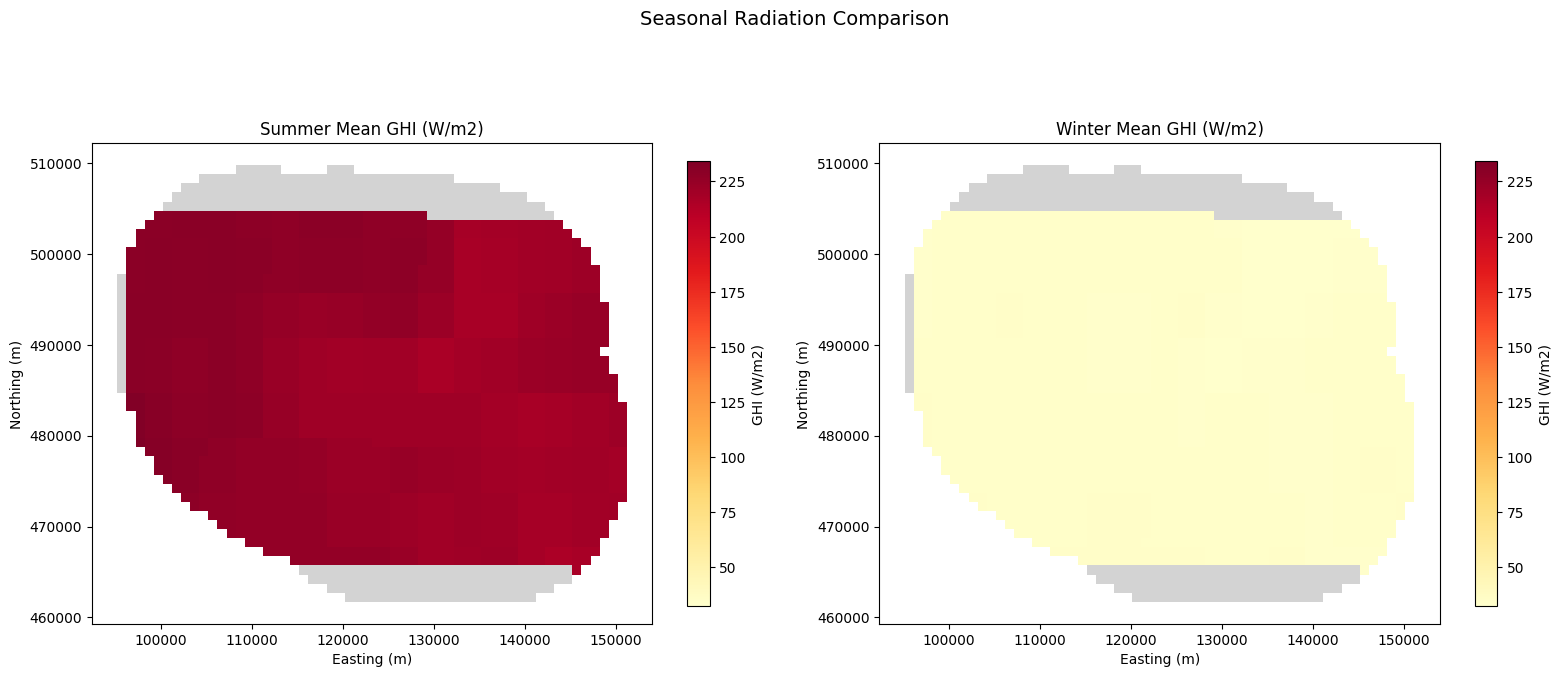

In [13]:
# 2. Summer vs Winter radiation side by side
has_summer = 'GHI_summer' in grid.columns and grid['GHI_summer'].notna().any()
has_winter = 'GHI_winter' in grid.columns and grid['GHI_winter'].notna().any()

if has_summer or has_winter:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    vmin = min(
        grid['GHI_summer'].min() if has_summer else 0,
        grid['GHI_winter'].min() if has_winter else 0,
    )
    vmax = max(
        grid['GHI_summer'].max() if has_summer else 1,
        grid['GHI_winter'].max() if has_winter else 1,
    )

    for ax, col, title in zip(
        axes,
        ['GHI_summer', 'GHI_winter'],
        ['Summer Mean GHI (W/m2)', 'Winter Mean GHI (W/m2)'],
    ):
        if col in grid.columns and grid[col].notna().any():
            grid.plot(
                column=col, ax=ax, cmap='YlOrRd',
                vmin=vmin, vmax=vmax,
                legend=True,
                legend_kwds={'label': 'GHI (W/m2)', 'shrink': 0.7},
                missing_kwds={'color': 'lightgrey'},
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')

    plt.suptitle('Seasonal Radiation Comparison', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Seasonal GHI columns not available.")

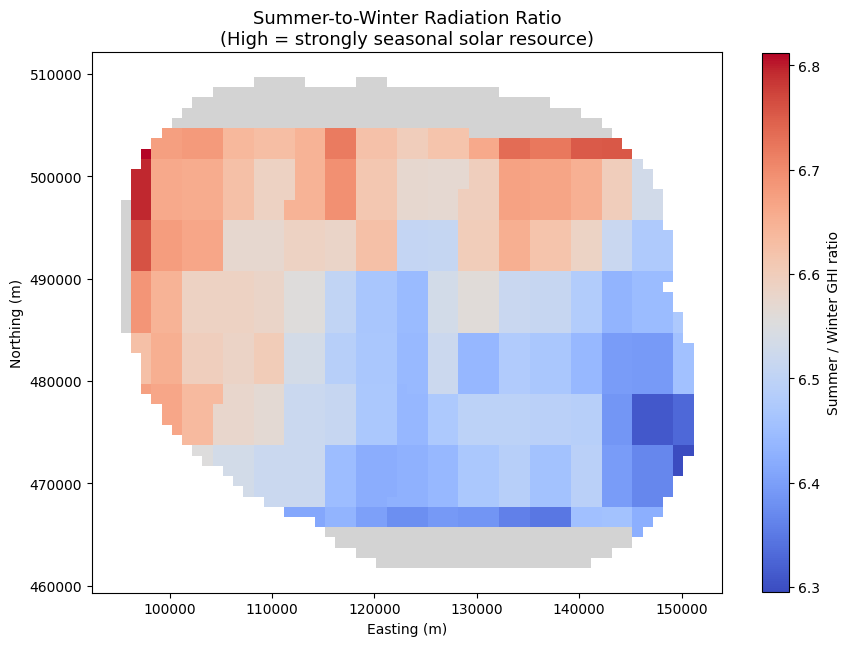

In [14]:
# 3. Seasonal ratio map
if 'GHI_seasonal_ratio' in grid.columns and grid['GHI_seasonal_ratio'].notna().any():
    fig, ax = plt.subplots(figsize=(9, 8))
    grid.plot(
        column='GHI_seasonal_ratio',
        ax=ax,
        cmap='coolwarm',
        legend=True,
        legend_kwds={'label': 'Summer / Winter GHI ratio', 'shrink': 0.7},
        missing_kwds={'color': 'lightgrey'},
    )
    ax.set_title('Summer-to-Winter Radiation Ratio\n(High = strongly seasonal solar resource)', fontsize=13)
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    plt.tight_layout()
    plt.show()
else:
    print("GHI_seasonal_ratio not available.")

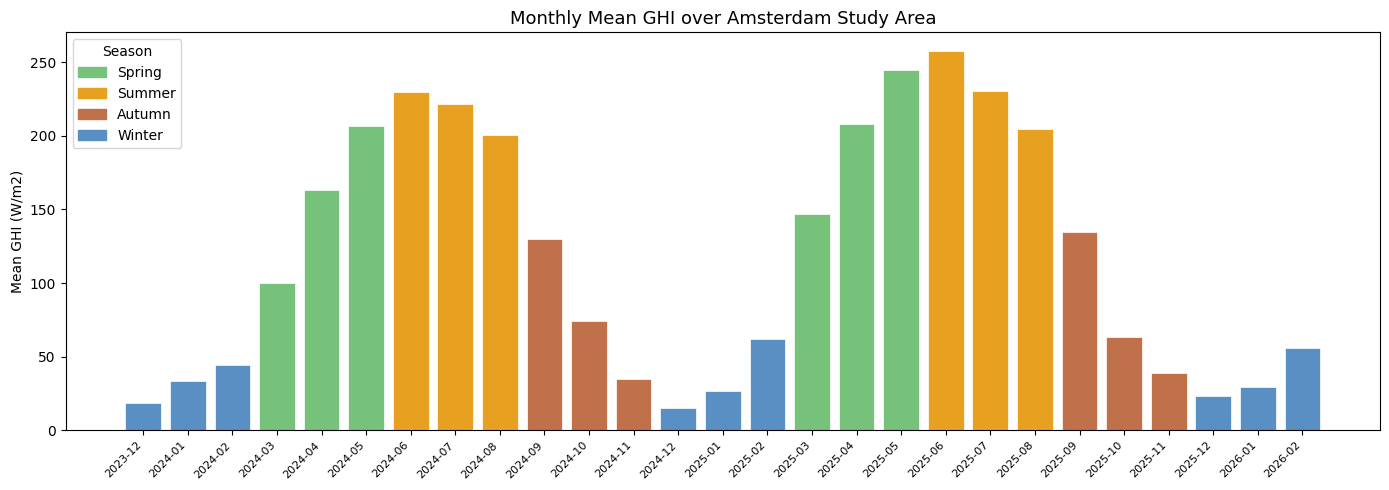

In [15]:
# 4. Monthly radiation time series for the full study area
if sis_data:
    months_sorted = sorted(sis_data, key=lambda r: (r['year'], r['month']))
    labels = [f"{r['year']}-{r['month']:02d}" for r in months_sorted]
    means = [float(np.nanmean(r['cell_values'])) for r in months_sorted]

    season_colors = {
        'spring': '#77c27b', 'summer': '#e8a020',
        'autumn': '#c0714a', 'winter': '#5a8fc4',
    }
    colors = [season_colors.get(r['season'], 'grey') for r in months_sorted]

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(labels)), means, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean GHI (W/m2)')
    ax.set_title('Monthly Mean GHI over Amsterdam Study Area', fontsize=13)

    patches = [mpatches.Patch(color=c, label=s.capitalize())
               for s, c in season_colors.items()]
    ax.legend(handles=patches, title='Season', loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No SIS data loaded -- time series chart skipped.")

## Section 8: Comparing Solar Radiation with Congestion Risk

<div style="background-color: #2a5081; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
This is the central step of Pipeline 2. We are combining the sunlight data we just computed with the congestion labels from Pipeline 1 to answer one question for every high-risk grid square: **is this square congested because solar panels are pushing too much electricity INTO the grid, or because people are pulling too much electricity OUT of the grid?**

</div>

<div style="background-color: #268146; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
The fix for congestion depends entirely on its cause:

| Cause of congestion | What is actually happening | Right solution |
|---|---|---|
| **Solar-driven** | Rooftop panels push electricity back into cables not built for two-way flow | Battery storage, smart inverters, local energy sharing |
| **Consumption-driven** | Too many devices pulling power faster than the cables can deliver | Thicker cables, new substations, demand flexibility |
| **Mixed (future risk)** | High sunlight but not yet high solar panel density | Proactive planning before panels arrive |

Choosing the wrong solution wastes money and does not fix the actual problem. A thicker cable does nothing to reduce reverse power flow from solar panels. The classification this section produces is the core added value of Pipeline 2.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work? -- The 2×2 Classification**

We use two simple thresholds -- the **median radiation** and the **median PV penetration** across all cells -- to place every high-risk cell into one of four categories:

|  | Above-median sunlight | Below-median sunlight |
|---|---|---|
| **Above-median solar panels** | ☀️ **Solar-driven** -- Strong sun + many panels = reverse power flow overloading cables | 🏭 **Consumption-driven** -- High PV but weak sun; congestion comes from demand |
| **Below-median solar panels** | 🌤️ **Mixed** -- Good sun but few panels yet; likely to become solar-driven in coming years | ✅ **Low / Medium risk** -- Neither strong solar nor high PV density; no urgent action |

**Why use the median as the threshold?**
The median is the middle value -- it splits the cells exactly in half into "above average" and "below average". Using the median makes the classification balanced and resistant to extreme outlier values that would skew a regular average (mean).

**Which cells are classified?**
Only **High-risk cells** from Pipeline 1 are classified as Solar-driven or Consumption-driven. Low and Medium risk cells are left as-is because they do not require urgent intervention and the driver distinction is less meaningful at lower congestion risk levels.

</div>


In [16]:
# Drop cells where key variables are missing
required = ['congestion_class', 'GHI_annual_mean']
comparison = grid.dropna(subset=required).copy()
print(f"Cells with complete congestion + radiation data: {len(comparison)} / {len(grid)}")

print("\nMean GHI by congestion class:")
class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
for cls, label in class_labels.items():
    subset = comparison[comparison['congestion_class'] == cls]
    if len(subset) == 0:
        print(f"  {label} (class {cls}): no cells")
        continue
    mean_ghi = subset['GHI_annual_mean'].mean()
    mean_pv = subset['pv_penetration'].mean() if 'pv_penetration' in subset.columns else float('nan')
    print(f"  {label} (class {cls}): GHI = {mean_ghi:.1f} W/m2, "
          f"PV penetration = {mean_pv:.3f}, n = {len(subset)}")

Cells with complete congestion + radiation data: 1430 / 2217

Mean GHI by congestion class:
  Low (class 0): GHI = 118.4 W/m2, PV penetration = 3.134, n = 477
  Medium (class 1): GHI = 118.9 W/m2, PV penetration = 19.854, n = 460
  High (class 2): GHI = 119.1 W/m2, PV penetration = 111.573, n = 493


In [17]:
# Compute median thresholds for classification
ghi_median = comparison['GHI_annual_mean'].median()
print(f"GHI median threshold: {ghi_median:.1f} W/m2")

if 'pv_penetration' in comparison.columns:
    pv_median = comparison['pv_penetration'].median()
    print(f"PV penetration median threshold: {pv_median:.4f}")
else:
    pv_median = None
    print("pv_penetration column not found -- solar driver detection will be based on GHI only")

GHI median threshold: 119.4 W/m2
PV penetration median threshold: 0.3425


In [18]:
def classify_congestion_driver(row):
    """Classify a grid cell into one of four congestion driver categories."""
    is_high_risk = row['congestion_class'] == 2
    is_high_ghi = row['GHI_annual_mean'] > ghi_median

    if pv_median is not None:
        pv_val = row.get('pv_penetration', 0)
        pv_val = 0 if pd.isna(pv_val) else pv_val
        has_high_pv = pv_val > pv_median
    else:
        has_high_pv = False

    if not is_high_risk:
        return 'Low/Medium risk'
    elif is_high_ghi and has_high_pv:
        return 'Solar-driven congestion'
    elif is_high_ghi and not has_high_pv:
        return 'Mixed drivers'
    else:
        return 'Consumption-driven congestion'


comparison['congestion_driver'] = comparison.apply(classify_congestion_driver, axis=1)

# Write back to the main grid
grid['congestion_driver'] = np.nan
grid.loc[comparison.index, 'congestion_driver'] = comparison['congestion_driver']

print("Congestion driver classification:")
print(comparison['congestion_driver'].value_counts().to_string())

Congestion driver classification:
congestion_driver
Low/Medium risk                  937
Consumption-driven congestion    223
Solar-driven congestion          163
Mixed drivers                    107


C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\1069552472.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Low/Medium risk' 'Low/Medium risk' 'Low/Medium risk' ...
 'Low/Medium risk' 'Consumption-driven congestion'
 'Consumption-driven congestion']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  grid.loc[comparison.index, 'congestion_driver'] = comparison['congestion_driver']


In [19]:
# Statistical summary: mean GHI and PV per driver category
cols_to_show = ['GHI_annual_mean', 'GHI_summer', 'GHI_winter']
if 'pv_penetration' in comparison.columns:
    cols_to_show.append('pv_penetration')
if 'consumption_kwh' in comparison.columns:
    cols_to_show.append('consumption_kwh')

summary = comparison.groupby('congestion_driver')[cols_to_show].mean().round(2)
print("\nMean values by congestion driver:")
print(summary.to_string())


Mean values by congestion driver:
                               GHI_annual_mean  GHI_summer  GHI_winter  pv_penetration  consumption_kwh
congestion_driver                                                                                      
Consumption-driven congestion           117.86      222.18       34.18          129.83      23351003.04
Low/Medium risk                         118.66      224.35       34.34           11.64       7361335.58
Mixed drivers                           120.08      227.71       34.69            0.27      21920562.04
Solar-driven congestion                 120.19      228.07       34.60          154.58      19550608.28


## Section 9: Combined Four-Panel Map

<div style="background-color: #234e86; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are drawing four maps side by side on the same page, each showing a different variable for the same 2,217 grid cells. Together they form the **main visual result** of Pipeline 2 -- the picture a grid planner would actually use to decide where to invest in infrastructure.

</div>

<div style="background-color: #207c40; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
Showing all four maps at the same scale and on the same grid makes it easy to spot patterns by eye. A planner can look at one square and immediately compare its congestion risk, sunlight level, PV installation density, and driver classification -- without switching between four separate files or trying to line up maps mentally. The bottom-right panel is the direct answer to the research question Pipeline 2 was built to answer.

</div>

<div style="background-color: #88731e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How to read the four panels:**

| Panel position | What it shows | Colour meaning |
|---|---|---|
| **Top-left** | Congestion risk class from Pipeline 1 | Green = Low, Yellow = Medium, Red = High |
| **Top-right** | Annual mean solar radiation (GHI) | Blue-green = low sunlight, Yellow-red = high sunlight |
| **Bottom-left** | PV penetration -- fraction of connections with solar panels | Light = few panels, Dark = many panels |
| **Bottom-right** | Congestion driver classification | Purple = Solar-driven, Orange = Consumption-driven, Grey = Mixed, White = Low/Medium risk |

Because all four panels use the exact same grid geometry, you can pick any square and read across all four to build a complete picture: "This cell is High risk, receives above-average sunlight, has many solar panels, and is therefore Solar-driven congestion."

</div>


C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\2137544905.py:67: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Congestion driver', loc='lower right', fontsize=7)
C:\Users\nmomc\AppData\Local\Temp\ipykernel_74224\2137544905.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Congestion driver', loc='lower right', fontsize=7)


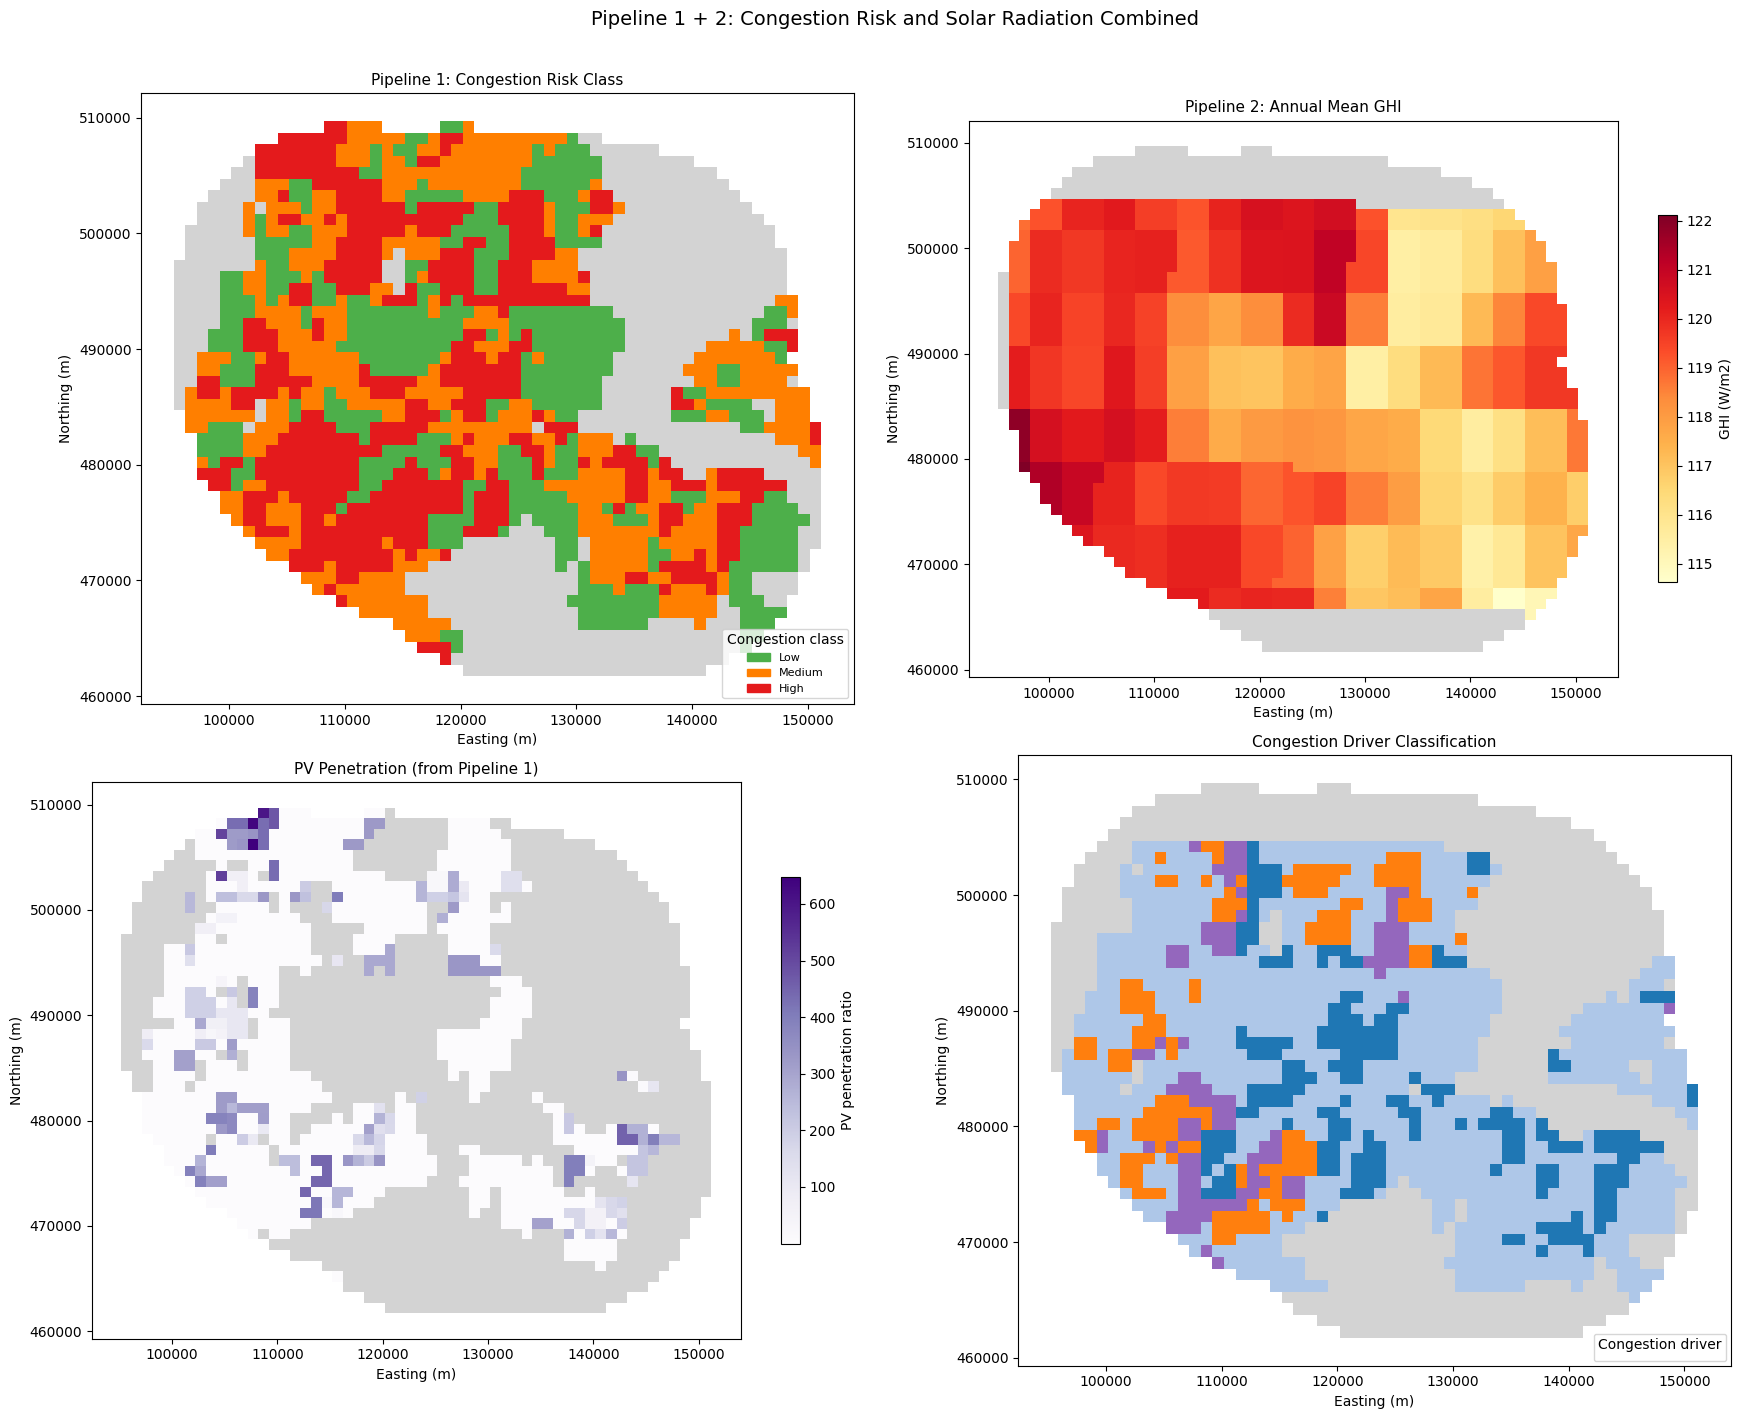

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# --- Top left: Congestion risk from Pipeline 1 ---
ax = axes[0]
if 'congestion_class' in grid.columns and grid['congestion_class'].notna().any():
    cmap_cong = ListedColormap(['#4daf4a', '#ff7f00', '#e41a1c'])
    norm_cong = BoundaryNorm([0, 1, 2, 3], cmap_cong.N)
    grid.plot(column='congestion_class', ax=ax, cmap=cmap_cong, norm=norm_cong,
              missing_kwds={'color': 'lightgrey'})
    patches = [
        mpatches.Patch(color='#4daf4a', label='Low'),
        mpatches.Patch(color='#ff7f00', label='Medium'),
        mpatches.Patch(color='#e41a1c', label='High'),
    ]
    ax.legend(handles=patches, title='Congestion class', loc='lower right', fontsize=8)
else:
    ax.text(0.5, 0.5, 'No congestion data', ha='center', va='center', transform=ax.transAxes)
ax.set_title('Pipeline 1: Congestion Risk Class', fontsize=11)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# --- Top right: Annual mean GHI ---
ax = axes[1]
if 'GHI_annual_mean' in grid.columns and grid['GHI_annual_mean'].notna().any():
    grid.plot(column='GHI_annual_mean', ax=ax, cmap='YlOrRd',
              legend=True,
              legend_kwds={'label': 'GHI (W/m2)', 'shrink': 0.6},
              missing_kwds={'color': 'lightgrey'})
else:
    ax.text(0.5, 0.5, 'No GHI data', ha='center', va='center', transform=ax.transAxes)
ax.set_title('Pipeline 2: Annual Mean GHI', fontsize=11)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# --- Bottom left: PV penetration ---
ax = axes[2]
if 'pv_penetration' in grid.columns and grid['pv_penetration'].notna().any():
    grid.plot(column='pv_penetration', ax=ax, cmap='Purples',
              legend=True,
              legend_kwds={'label': 'PV penetration ratio', 'shrink': 0.6},
              missing_kwds={'color': 'lightgrey'})
else:
    ax.text(0.5, 0.5, 'No PV data', ha='center', va='center', transform=ax.transAxes)
ax.set_title('PV Penetration (from Pipeline 1)', fontsize=11)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# --- Bottom right: Congestion driver type ---
ax = axes[3]
driver_colors = {
    'Low/Medium risk': '#aec7e8',
    'Solar-driven congestion': '#ff7f0e',
    'Consumption-driven congestion': '#1f77b4',
    'Mixed drivers': '#9467bd',
}

if 'congestion_driver' in grid.columns and grid['congestion_driver'].notna().any():
    for driver, color in driver_colors.items():
        subset = grid[grid['congestion_driver'] == driver]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, label=driver)
    # Cells without a driver assignment
    no_driver = grid[grid['congestion_driver'].isna()]
    if len(no_driver) > 0:
        no_driver.plot(ax=ax, color='lightgrey', label='No data')
    ax.legend(title='Congestion driver', loc='lower right', fontsize=7)
else:
    ax.text(0.5, 0.5, 'No driver data', ha='center', va='center', transform=ax.transAxes)
ax.set_title('Congestion Driver Classification', fontsize=11)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

plt.suptitle('Pipeline 1 + 2: Congestion Risk and Solar Radiation Combined', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Section 10: Exporting the Final Grid

<div style="background-color: #196cd8; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are saving the completed analysis -- all 2,217 grid squares with every feature from Pipeline 1 plus every new radiation column and the congestion driver classification -- into a single portable file called `congestion_radiation_grid.gpkg`. This file is the finished product of both pipelines combined.

</div>

<div style="background-color: #1a8a41; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
A Jupyter notebook is a workspace for analysis -- it is not a deliverable product in itself. Grid engineers, urban planners, and GIS analysts need the data in a standard geographic format they can open in professional software like **QGIS** or **ArcGIS** without needing to know Python at all. The GeoPackage format (`.gpkg`) is the modern open standard for this: a single portable file that stores both the data table and the map geometry, readable by virtually all GIS software worldwide.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

`grid.to_file(export_path, driver='GPKG')` -- this one line tells GeoPandas to write the entire GeoDataFrame (2,217 rows, all columns, all square outlines) to a GeoPackage file on disk.

**What columns does the exported file contain?**
- Everything from Pipeline 1: congestion class and probability, satellite features (NDVI, NDBI, spectral bands), CBS demographic statistics, Liander PV and energy data
- Everything added in Pipeline 2: monthly GHI values, seasonal averages, seasonal ratio, annual total in kWh/m², and the congestion driver label

**What is this file used for next?**
This file is the handoff point to any downstream step: a planning dashboard, a GIS analysis by a network engineer, a printed report, or a further modelling experiment. It contains the complete picture of Amsterdam's electricity grid congestion -- both **where** the risk is high and **why**.

</div>


In [21]:
export_path = BASE_DIR / 'congestion_radiation_grid.gpkg'

# Select columns to export (skip raw monthly SIS columns to keep file size manageable)
desired_cols = [
    'cell_id', 'geometry',
    'congestion_class', 'congestion_label', 'pred_class', 'pred_proba_high',
    'GHI_annual_mean', 'GHI_annual_kWh_m2',
    'GHI_spring', 'GHI_summer', 'GHI_autumn', 'GHI_winter', 'GHI_seasonal_ratio',
    'pv_penetration', 'feedin_ratio', 'consumption_kwh',
    'congestion_driver', 'land_use_type',
    'bevolkingsdichtheid_inwoners_per_km2', 'NDVI_summer', 'NDBI_summer',
]
export_cols = [c for c in desired_cols if c in grid.columns]
missing = [c for c in desired_cols if c not in grid.columns]

if missing:
    print(f"Columns not present in grid (skipped): {missing}")

grid[export_cols].to_file(export_path, driver='GPKG')
print(f"Saved {len(grid)} cells with {len(export_cols)} columns to:")
print(f"  {export_path}")

Columns not present in grid (skipped): ['NDVI_summer', 'NDBI_summer']
Saved 2217 cells with 19 columns to:
  C:\Nikola\Year 3\Semester 5\Notebook\congestion_radiation_grid.gpkg


## Section 11: Conclusions

<div style="background-color: #1e4981; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

### What Pipeline 2 adds to Pipeline 1

Pipeline 1 trained a Random Forest machine learning model to predict grid congestion risk for each 1 km² cell in Amsterdam. It used features such as PV penetration, feed-in ratio, electricity consumption, population density, vegetation cover (NDVI), and urban density (NDBI). The model outputs a congestion class (Low / Medium / High) and a probability score for each cell.

Pipeline 2 adds a **physical explanation layer** on top of those statistical predictions. By mapping CM SAF Meteosat radiation onto the same grid, we can now ask: is this high-risk cell exposed to strong sunlight AND dense rooftop solar? Or is it congested for an entirely different reason?

</div>

<div style="background-color: #268146; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

### Solar-driven vs Consumption-driven -- why the distinction matters

The four-category driver classification allows network planners to match the right solution to each area:

- **Solar-driven** cells have both high radiation and high PV penetration. On sunny summer afternoons, the reverse power flow overloads cables and transformers that were only designed to carry electricity in one direction -- from the substation to the homes. **Battery storage, dynamic curtailment agreements, and local energy sharing** are effective here.

- **Consumption-driven** cells have high congestion risk but low solar input or low PV density. The problem is demand outpacing delivery capacity -- too many electric vehicles, heat pumps, and commercial loads drawing power simultaneously. **Cable reinforcement, new substations, and demand flexibility programmes** are the right response.

- **Mixed** cells sit in high-radiation areas without proportionally high PV density yet. These may become solar-driven within a few years as solar panel adoption continues to grow rapidly across the Netherlands. They warrant **proactive infrastructure planning today** -- before congestion becomes severe.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

### Seasonal patterns -- the summer concentration effect

Amsterdam sits at latitude 52°N. The summer-to-winter radiation ratio across the study area is approximately **6.5:1** -- the city receives roughly 6.5 times more solar energy in June--August than in December--February. This means:

- Solar electricity generation is heavily concentrated into a 3-month summer window
- Even where congestion is currently consumption-driven, future solar growth could shift the cause within just a few years
- Grid upgrades planned today must account for **where PV adoption is heading**, not only where it stands right now

The spatial radiation map produced here is therefore an important **forward-looking planning input**, not just a snapshot of today's situation.

</div>

<div style="background-color: #7a3030; border-left: 5px solid #dc2626; padding: 12px; margin: 8px 0; border-radius: 4px;">

### Limitations and next steps

**Radiation resolution:** The CM SAF SIS data has a native resolution of approximately 5.5 km. All grid cells within a single Meteosat pixel receive exactly the same radiation value. Local shading from tall buildings or dense tree canopy is not captured. A higher-resolution radiation product or a building-shadow modelling step would improve per-cell accuracy.

**PV data currency:** The PV penetration values from Pipeline 1 are derived from Liander's published open data and may undercount installations added after the reference year. As the Dutch government continues to subsidise rooftop solar, rapid PV growth is expected -- this could shift the driver classification of many currently Mixed or Consumption-driven cells toward Solar-driven within just 2--3 years.

**No measured ground truth for driver classification:** The Solar-driven / Consumption-driven split is based on median thresholds for radiation and PV, not on actual measured power flows at individual substations. A future version could validate this classification against Liander's substation congestion reports once those become publicly available with geographic coordinates.

</div>


## Section 12: How Pipeline 1 and Pipeline 2 Work Together

<div style="background-color: #1e3a5f; color: white; padding: 20px; border-radius: 8px; margin: 10px 0;">

### The two notebooks tell one complete story

Neither pipeline is useful on its own. Pipeline 1 finds the danger zones. Pipeline 2 explains why each danger zone is dangerous. Together they give grid planners everything they need to choose the right solution for each neighbourhood.

</div>

<div style="background-color: #1e4981; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we showing here?**
A step-by-step diagram of how data flows from raw inputs all the way through both pipelines to the final deliverable, and a summary table comparing what each pipeline contributes.

</div>

---

### The Flow of Data Between the Two Pipelines

```
┌─────────────────────────────────────────────────────────────┐
│         PIPELINE 1  (congestion_analysis.ipynb)             │
│                                                             │
│  Sentinel-2 satellite photos  ──┐                           │
│  CBS population statistics    ──┤─── Random Forest model    │
│  Liander energy data          ──┘          │                │
│  BAG building types           ──┘          ▼                │
│                                   congestion_risk_grid.gpkg │
│                              (Low / Medium / High per km²)  │
└──────────────────────────────────────┬──────────────────────┘
                                       │  shared file
                                       ▼
┌─────────────────────────────────────────────────────────────┐
│        PIPELINE 2  (radiation_estimation.ipynb)             │
│                                                             │
│  congestion_risk_grid.gpkg  ──┐                             │
│  Meteosat SIS radiation     ──┤── nearest-neighbour mapping │
│  (27 monthly NetCDF files)  ──┘          │                  │
│                                          ▼                  │
│                           Solar-driven vs Consumption-      │
│                           driven classification             │
│                                          │                  │
│                                          ▼                  │
│                          congestion_radiation_grid.gpkg     │
│                          (WHY each km² is congested)        │
└─────────────────────────────────────────────────────────────┘
```

---

<div style="background-color: #1e703b; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why are two pipelines better than one?**

Pipeline 1 uses machine learning to find patterns in the data and predict risk. It is very good at identifying **where** a problem exists, because it can spot subtle combinations of features (vegetation, population, energy consumption) that together signal high congestion risk -- even in places where Liander has no published data.

Pipeline 2 uses physical satellite measurements to add an explanation. Machine learning models are sometimes called "black boxes" because they produce a prediction without fully explaining why. Pipeline 2 opens that box a little by asking: does this high-risk area receive a lot of sunlight? Does it have many solar panels? If yes, the physics of electricity generation tells us the cause.

**You need both:** the statistical model to find the hotspots, and the physical radiation data to understand them.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How are the pipelines technically linked?**

The two pipelines are connected by one shared file and one shared spatial framework:

1. **Shared file:** `congestion_risk_grid.gpkg` -- Pipeline 1 writes it; Pipeline 2 reads it as its starting point.
2. **Shared grid:** 2,217 one-kilometre squares in the Dutch coordinate system (EPSG:28992, distances in metres). Because both pipelines use the exact same squares with the exact same geometry, every column from Pipeline 1 and every column from Pipeline 2 lines up row-by-row with no extra spatial joining needed.
3. **Shared cell IDs:** The `cell_id` column (0 to 2,216) is the key that links the two datasets. A planner can look up cell 1,042 in the Pipeline 1 output and cell 1,042 in the Pipeline 2 output and know they are referring to exactly the same one-kilometre square of Amsterdam.

</div>

<div style="background-color: #2b974b; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Summary comparison table**

| | Pipeline 1 | Pipeline 2 (this notebook) |
|---|---|---|
| **Question answered** | Where is congestion risk highest? | Why is each high-risk cell congested? |
| **Main inputs** | Sentinel-2 photos + CBS stats + Liander energy data | Meteosat SIS radiation (27 months) + Pipeline 1 output file |
| **Method** | Random Forest classifier (machine learning) | Nearest-neighbour radiation mapping + 2x2 threshold classification |
| **Main output** | Low / Medium / High risk class per km² | Solar-driven / Consumption-driven / Mixed per km² |
| **Output file** | `congestion_risk_grid.gpkg` | `congestion_radiation_grid.gpkg` |
| **Grid used** | 2,217 x 1 km² squares, EPSG:28992 | Same 2,217 squares -- loaded from Pipeline 1 file |
| **Recommended action** | Prioritise high-risk cells for further investigation | Match the right technical solution to the right driver type |

</div>
